In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
!nvidia-smi

Sun Mar 15 10:05:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install datasets torchvision torch scikit-learn matplotlib

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim

from datasets import load_dataset

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
dataset = load_dataset(
    "dpdl-benchmark/plant_village",
    split="train"
)

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/368 [00:00<?, ?B/s]

data/train-00000-of-00013.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00001-of-00013.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

data/train-00002-of-00013.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

...

data/train-00010-of-00013.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

data/train-00011-of-00013.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00012-of-00013.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/54303 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'image/filename', 'label'],
    num_rows: 54303
})


In [8]:
print(dataset)

Dataset({
    features: ['image', 'image/filename', 'label'],
    num_rows: 54303
})


In [6]:
sample = dataset[0]

print(sample)

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=256x256 at 0x78E0799FE030>, 'image/filename': "b'image (785).JPG'", 'label': 35}


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

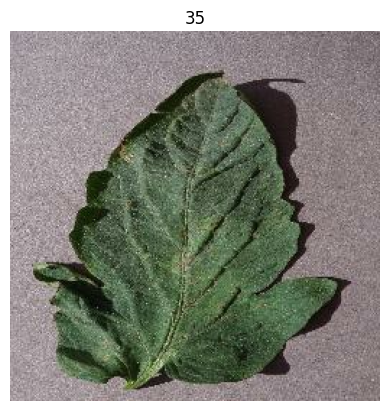

In [7]:
plt.imshow(sample["image"])
plt.title(sample["label"])
plt.axis("off")

label distribution visualization

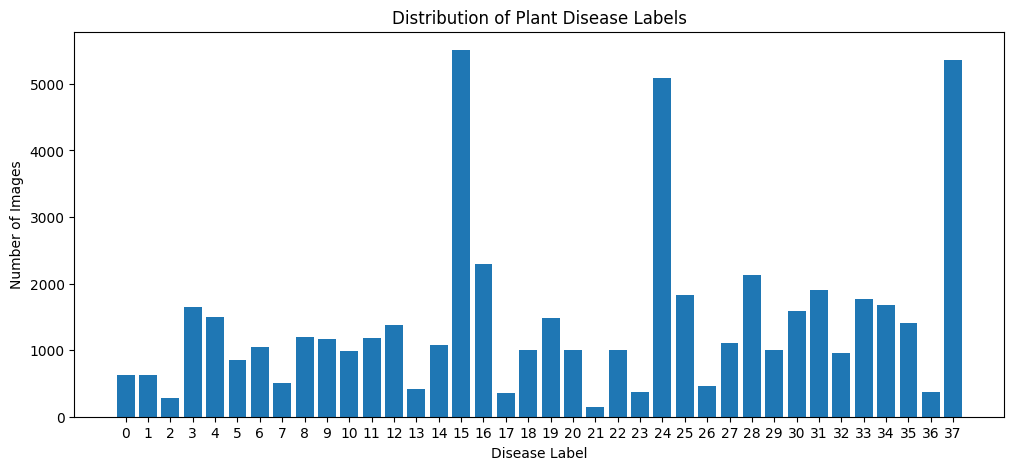

In [18]:
from collections import Counter
import matplotlib.pyplot as plt

labels = [sample["label"] for sample in dataset]

label_counts = Counter(labels)

plt.figure(figsize=(12,5))
plt.bar(label_counts.keys(), label_counts.values())

plt.xlabel("Disease Label")
plt.ylabel("Number of Images")
plt.title("Distribution of Plant Disease Labels")

plt.xticks(list(label_counts.keys()))

plt.show()

Splitting the dataset

In [19]:
dataset_split = dataset.train_test_split(test_size=0.2, seed=42)

train_ds = dataset_split["train"]
test_ds = dataset_split["test"]

print(len(train_ds), len(test_ds))

43442 10861


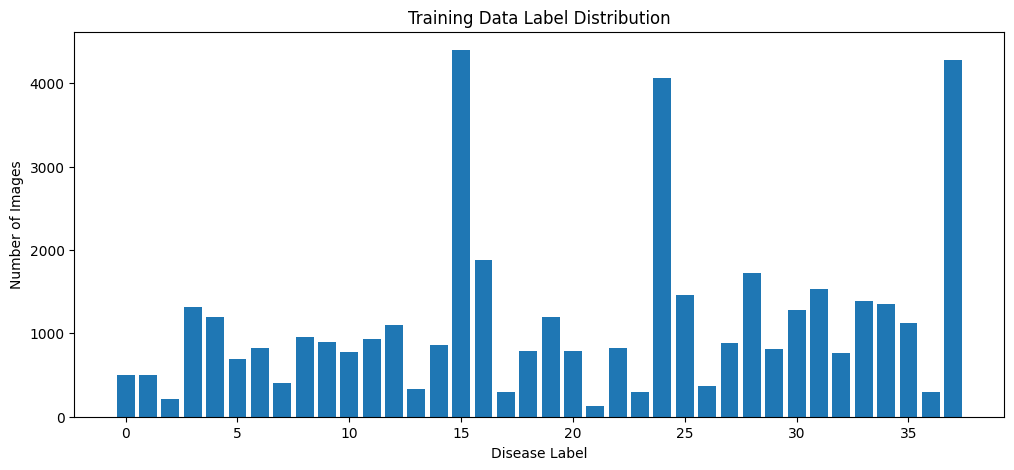

In [20]:
from collections import Counter
import matplotlib.pyplot as plt

train_labels = [sample["label"] for sample in train_ds]

counts = Counter(train_labels)

plt.figure(figsize=(12,5))
plt.bar(counts.keys(), counts.values())

plt.xlabel("Disease Label")
plt.ylabel("Number of Images")
plt.title("Training Data Label Distribution")

plt.show()

Image Transformations

In [21]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

Creating a PyTorch Dataset Wrapper

In [24]:


class PlantDiseaseDataset(torch.utils.data.Dataset):

    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        sample = self.dataset[idx]

        image = sample["image"]
        label = sample["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

Creating Training and Testing Datasets

In [25]:
train_dataset = PlantDiseaseDataset(train_ds, transform)
test_dataset = PlantDiseaseDataset(test_ds, transform)

Creating DataLoaders

In [26]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

Verifying the Pipeline

In [27]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


loading ResNet18

In [28]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 122MB/s]


In [30]:
num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 38)

In [31]:
model = model.to(device)

Defining Loss Function

In [32]:
criterion = nn.CrossEntropyLoss()

Defining Optimizer

In [33]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.0003)

training loop

In [34]:
epochs = 5

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

Epoch 1, Loss: 0.17520554833126492
Epoch 2, Loss: 0.05677939753680948
Epoch 3, Loss: 0.047465705162597294
Epoch 4, Loss: 0.0340931352151159
Epoch 5, Loss: 0.03307661354737533


Evaluation

In [35]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 98.37%


confusion matrics

In [36]:
from sklearn.metrics import classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95       128
           1       1.00      0.98      0.99       123
           2       1.00      1.00      1.00        57
           3       0.99      0.99      0.99       330
           4       0.99      1.00      1.00       301
           5       1.00      0.96      0.98       164
           6       0.99      0.98      0.98       224
           7       0.92      0.96      0.94       113
           8       0.92      1.00      0.96       239
           9       0.99      1.00      1.00       266
          10       0.99      0.94      0.97       211
          11       0.95      1.00      0.98       243
          12       1.00      0.96      0.98       278
          13       1.00      1.00      1.00        93
          14       1.00      1.00      1.00       219
          15       1.00      1.00      1.00      1107
          16       1.00      1.00      1.00       420
          17       0.97    

Saving the model

In [37]:
torch.save(model.state_dict(), "plant_disease_resnet18.pth")